### Using Euler's method, solve:

● dy/dx =-2y*cos(x), y(0) = 1

● over an interval, x∈(0,10pi) and a step size, h of (.01, .05, .15, .2, .25 … 1)

● average the y values of for each run of h

● compare/plot the error between each run

● compare the the values of y for x ≈ 15 (close to 15) for each run

● compare/plot the local error

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
step_sizes = np.arange(0.01, 1.01, 0.05)
x_start, x_end = 0, 10 * np.pi

# Function
def f(x, y):
    return -2 * y * np.cos(x)

# Storage
all_x = []
all_y = []
all_h = []
avg_y_values = []
y_at_15 = []

# FIRST PASS: run Euler + store everything
for h in step_sizes:

    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    y_values[0] = 1

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    all_x.append(x_values)
    all_y.append(y_values)
    all_h.append(h)

    # Average y
    avg_y_values.append(np.mean(y_values))

    # y near x ≈ 15
    idx_15 = np.argmin(np.abs(x_values - 15))
    y_at_15.append(y_values[idx_15])

# Reference (first run)
first_run_x = all_x[0]
first_run_y = all_y[0]

# SECOND PASS: compute errors
avg_errors = []
local_errors_15 = []

for i in range(len(all_h)):

    x_values = all_x[i]
    y_values = all_y[i]
    h = all_h[i]

    # Interpolate onto reference grid
    y_interp = np.interp(first_run_x, x_values, y_values)

    error = np.abs(y_interp - first_run_y)

    # Metrics for plots
    avg_errors.append(np.mean(error))

    idx_15 = np.argmin(np.abs(first_run_x - 15))
    local_errors_15.append(error[idx_15])

    total_error = np.sum(error)

    # Print output (matches requirements)
    print(f"\nStep size h = {round(h,2)}")
    print("Average y value:", avg_y_values[i])
    print("y near x ≈ 15:", y_at_15[i])
    print("Error at each point:")
    print(error)
    print("Total accumulated error:", total_error)
    print("-" * 50)


Step size h = 0.01
Average y value: 1.9101617792186754
y near x ≈ 15: 0.2324896386610591
Error at each point:
[0. 0. 0. ... 0. 0. 0.]
Total accumulated error: 0.0
--------------------------------------------------

Step size h = 0.06
Average y value: 0.884905389567876
y near x ≈ 15: 0.1042254523988114
Error at each point:
[0.00000000e+00 1.91021968e-05 3.62775968e-04 ... 6.03087307e-01
 5.91292578e-01 5.79799701e-01]
Total accumulated error: 3219.805225721949
--------------------------------------------------

Step size h = 0.11
Average y value: 0.48065123161642326
y near x ≈ 15: 0.04286503543849603
Error at each point:
[0.00000000e+00 3.82043935e-05 3.24571575e-04 ... 7.29198068e-01
 7.14747654e-01 7.00599092e-01]
Total accumulated error: 4491.86099286092
--------------------------------------------------

Step size h = 0.16
Average y value: 0.29112883962400604
y near x ≈ 15: 0.019054816287470553
Error at each point:
[0.00000000e+00 3.18369946e-05 3.37306373e-04 ... 7.54817266e-01
 7

You'll have 3 plots:

● one plot compare Euler's method for each value of h

● one plot for the average error between runs, avg error vs h

● one plot for the local error at x ≈ 15 for each run, local error vs h

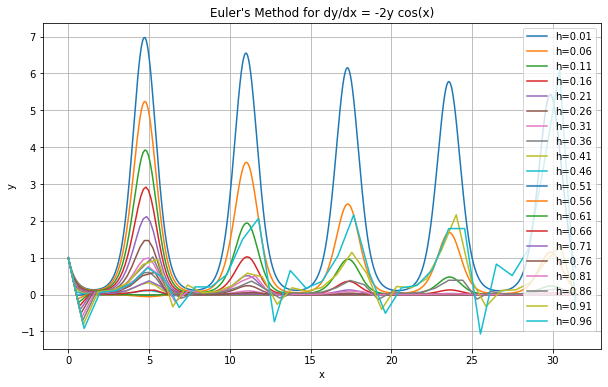

In [7]:
# Compare Euler's method for each value of h
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for i in range(len(all_h)):
    plt.plot(all_x[i], all_y[i], label=f"h={round(all_h[i],2)}")

plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method for dy/dx = -2y cos(x)")
plt.legend()
plt.grid()
plt.show()

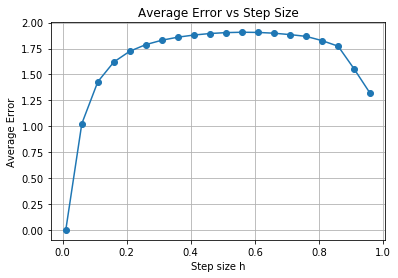

In [8]:
# Average error between runs, avg error vs h
plt.figure()

plt.plot(all_h, avg_errors, marker='o')

plt.xlabel('Step size h')
plt.ylabel('Average Error')
plt.title('Average Error vs Step Size')
plt.grid()

plt.show()   

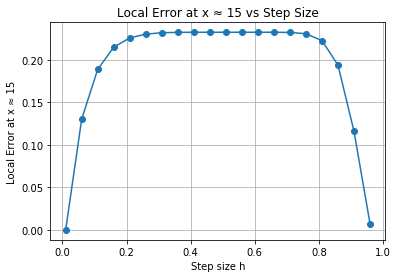

In [9]:
# Local error at x ≈ 15 for each run, local error vs h
plt.figure()

plt.plot(all_h, local_errors_15, marker='o')

plt.xlabel('Step size h')
plt.ylabel('Local Error at x ≈ 15')
plt.title('Local Error at x ≈ 15 vs Step Size')
plt.grid()

plt.show()

### Explanation of results:

The plots show that as the step size h increases, Euler’s method becomes less accurate. This happens because Euler’s method is a first-order approximation, so the numerical error grows proportionally with the step size. The local error near 
x≈15 highlights how inaccuracies can accumulate unevenly, especially over longer intervals.

# Addendum - Stability Analysis
Look at f(x,y), can we do a Stability Analysis on -2y*cos(x)?

How can we apply what we've done with f(x,y) = -2y? How with that x component? What's our λ?

● Find the stability condition for -2y*cos(x)

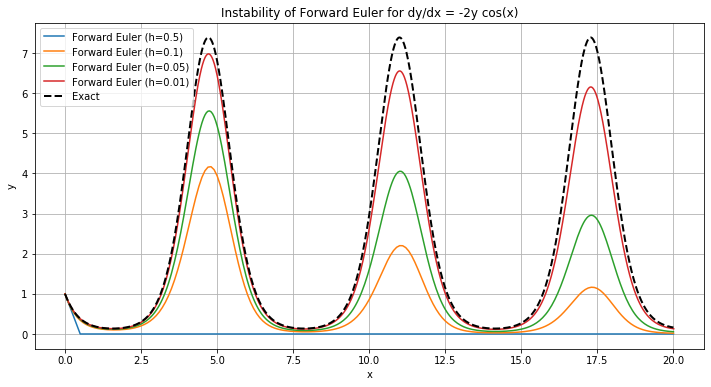

In [10]:
def f(x, y):
    return -2 * y * np.cos(x)

def forward_euler(h, x_start, x_end, y0):
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    y_values[0] = y0

    for i in range(1, len(x_values)):
        x_n = x_values[i-1]
        y_n = y_values[i-1]
        y_values[i] = y_n + h * f(x_n, y_n)

    return x_values, y_values

# Exact solution
def y_exact(x):
    return np.exp(-2 * np.sin(x))

# Parameters
x_start = 0
x_end = 20
y0 = 1

h_values = [0.5, 0.1, 0.05, 0.01]

plt.figure(figsize=(12,6))

# Plot numerical solutions
for h in h_values:
    x, y = forward_euler(h, x_start, x_end, y0)
    plt.plot(x, y, label=f'Forward Euler (h={h})')

# Plot exact solution
x_fine = np.linspace(x_start, x_end, 2000)
plt.plot(x_fine, y_exact(x_fine), 'k--', linewidth=2, label='Exact')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Instability of Forward Euler for dy/dx = -2y cos(x)')
plt.legend()
plt.grid(True)
plt.show()

### Comments on Stability
As we can see in our stability analysis, 
When cos(x)>0: solution behaves nicely
When cos(x)<0: solution starts growing artificially

Smaller step sizes get closer, but still not perfect. Even with small step sizes, Forward Euler accumulates error during intervals where cos(x)<0, causing exponential growth that is not present in the true solution.